/tmp/ipykernel_28503/1464120826.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


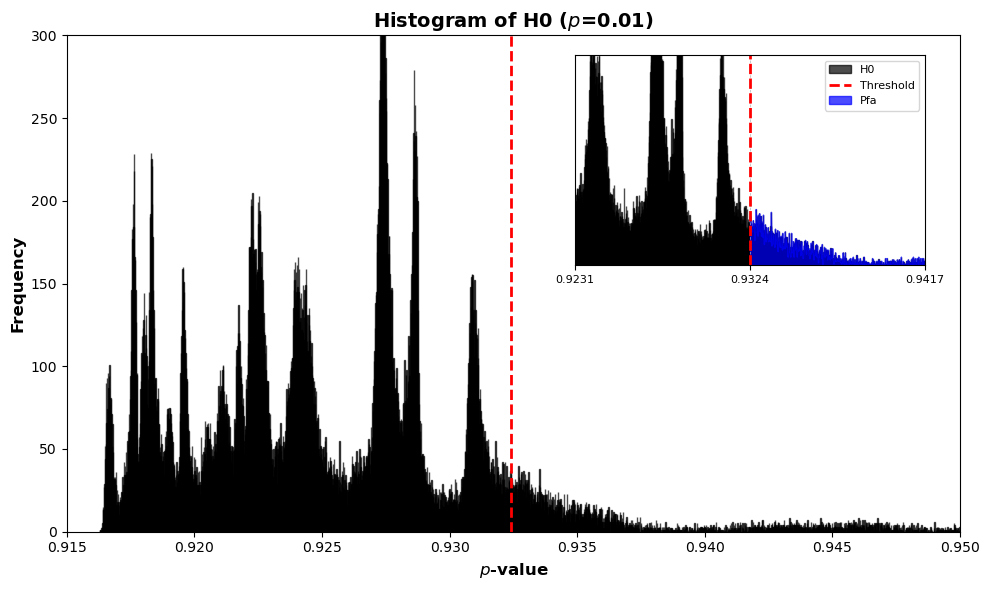

In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------- Load CSV Function ----------------------------- #
def load_csv_from_folder(folder_path):
    """Load and concatenate all CSV files in a folder."""
    files = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.csv')]
    dataframes = [pd.read_csv(file) for file in files]
    return pd.concat(dataframes, ignore_index=True)

# ------------------------------ Load the Data ------------------------------- #
FOLDER = "measurements_bad"
H0_FOLDER = FOLDER + "/H0/normalized"

# Assuming CSVs are available, otherwise provide the correct directory
h0_data = load_csv_from_folder(H0_FOLDER)
    
# Select the column for P=0.01
column = "ED (P=0.01)"
data = h0_data[column]

# ----------------------------- Compute Histogram ----------------------------- #
hist_values, bin_edges = np.histogram(data, bins=3000, density=False)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Define threshold (e.g., 0.94)
threshold = 0.9324

# Compute CDF (normalized cumulative sum)
cdf_values = np.cumsum(hist_values) / np.sum(hist_values)

# Find the index where the threshold crosses
threshold_index = np.searchsorted(bin_centers, threshold)

# ------------------------------- Compute Zoom Limits ------------------------------ #
zoom_margin = 0.01  # margin on each side
x_min_zoom = threshold - (threshold * zoom_margin)
x_max_zoom = threshold + (threshold * zoom_margin)

# Filter data for zoomed-in region
zoom_mask = (bin_centers >= x_min_zoom) & (bin_centers <= x_max_zoom)
zoom_bin_centers = bin_centers[zoom_mask]
zoom_hist_values = hist_values[zoom_mask]

# ------------------------------- Plot Setup ---------------------------------- #
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Main Histogram (Black)
ax.bar(bin_centers, hist_values, width=np.diff(bin_edges), color='black', alpha=0.7, edgecolor='black', label="H0")

# Add Vertical Line (Red)
ax.axvline(threshold, color='red', linestyle='--', linewidth=2, label="Threshold")

# Shade the CDF region (Blue)
# ax.fill_between(bin_centers[threshold_index:], hist_values[threshold_index:], color='blue', alpha=0.3, label="Pfa")

# --------------------------- Formatting for Scientific Style ---------------- #
ax.set_ylim(0, 300)  # Set Y limit
ax.set_xlim(0.915, 0.95)
ax.set_xlabel("$p$-value", fontsize=12, weight='bold')
ax.set_ylabel("Frequency", fontsize=12, weight='bold')
ax.set_title(f"Histogram of H0 ($p$=0.01)", fontsize=14, weight='bold')
ax.tick_params(axis='both', which='major', labelsize=10)
# ax.legend(fontsize=10, loc='upper left')
# ax.grid(visible=True, which='both', linestyle='--', linewidth=0.5)

# ------------------------------ Zoomed-in Subplot --------------------------- #
ax_zoom = fig.add_axes([0.58, 0.55, 0.35, 0.35])  # Position of the zoomed-in plot

# Plot Zoomed-in Histogram (Black)
bars = ax_zoom.bar(zoom_bin_centers, zoom_hist_values, width=np.diff(bin_edges[:len(zoom_hist_values)+1]), 
                   color='black', alpha=0.7, edgecolor='black', label="H0")

# Add Vertical Line (Red)
line = ax_zoom.axvline(threshold, color='red', linestyle='--', linewidth=2, label="Threshold")

# Shade the CDF region (Blue) only in the zoomed-in plot
fill = ax_zoom.fill_between(zoom_bin_centers[zoom_bin_centers >= threshold], 
                            zoom_hist_values[zoom_bin_centers >= threshold], 
                            color='blue', alpha=0.7, label="Pfa")

# Remove legend in the zoomed-in plot
ax_zoom.set_xlim(x_min_zoom, x_max_zoom)
ax_zoom.set_ylim(0, 150)  # Adjust y-limit for zoom

# Set X-axis labels for zoom (min, middle, max)
x_ticks_zoom = [x_min_zoom, threshold, x_max_zoom]
ax_zoom.set_xticks(x_ticks_zoom)
ax_zoom.set_xticklabels([f"{x:.4f}" for x in x_ticks_zoom], fontsize=8)

# Hide y ticks
ax_zoom.set_yticks([])

ax_zoom.legend(handles=[bars, line, fill], fontsize=8, loc='upper right')
ax_zoom.grid(visible=True, which='both', linestyle='--', linewidth=0.5)

# Display the plot
plt.tight_layout()
plt.show()

# save the image
fig.savefig("histogram_H0_p001.png", dpi=300, bbox_inches='tight')

